In [1]:
from spd.OperatorSequence import *
from spd.SparsePauliDynamics import *
from qiskit.quantum_info import PauliList
import numpy as np
import matplotlib.pyplot as plt

from quantum_simulation_recipe.plot_config import *

Matplotlib is building the font cache; this may take a moment.


### Simple example with 5 qubits

The circuit is U = (A * B)^3.
Observable is ZZIII.
A is composed of 5 Pauli rotation gates e^(-i theta * P / 2), where P are
YYIYI, IYYII, IIYIY, IYYYI, YIYII.
B is composed of 5 single qubit rotations around Z (ZIIII, IZIII, ...).
We order the operations by their order of acting on the observable in the Heisenberg picture, not by the action on the state 
(i.e., the first operator is the first one applied to the observable).

Rotation angles are all equal to 1.7. In our code we do not store theta, but theta/2 (i.e. coefficients c are stored and Pauli rotation gates are e^(-i * c * P)).
So the coefficients are 0.85 and must be provided as a list (of size n_layers, which is in this case 3 steps x 2 layers per step = 6) of lists 
(each list is of the size of the number of Pauli operators in a given layer).
Here, each layer contains 5 Pauli rotation gates, so the coefficients are provided as a list of 6 lists of lengths equal to 5.

OperatorSequence is a class that stores the circuit composed of Pauli rotation gates (it stores the lists of coefficients and Pauli operators).
Pauli operators are provided as a list of Qiskit's PauliList objects. PauliList objects can have different numbers of Paulis in principle (here they all contain 5 Paulis).

Once we have set up the observable and the OperatorSequence, we can initialize SPD Simulation (from SparsePauliDynamics module).
Simulation takes as input the observable, operator sequence, number of layers in the operator sequence (in our case 6), and a threshold (set to zero for exact simulation).
Once we have an instance sim of Simulation, we can run it with sim.run(), which will return the expectation value
<0| U^dag O U |0>, where U is our circuit defined by a sequence of Pauli rotation gates. It is returned as a complex number, although in most applications this will be a real number.


In [6]:
nq = 5
nsteps = 10
obs = PauliList(['ZZIII'])
A_op = PauliList(['YYIYI', 'IYYII', 'IIYIY', 'IYYYI', 'YIYII'])
B_op = PauliList(['ZIIII', 'IZIII', 'IIZII', 'IIIZI', 'IIIIZ'])
ops = [A_op, B_op]  * nsteps
coeffs = [[0.85 for _ in range(nq)] for i in range(2*nsteps)] 
op_seq = OperatorSequence(ops, coeffs).to_sparse_pauli_list()

def count_weight(pstr):
    # print(pstr, list(pstr))
    return sum([1 for c in list(pstr) if c != 'I'])

In [7]:
pstrs_bit = unpackbits(sim_exact.observable.bits,nq)
print(len(pstrs_bit), "bit strings in the simulation result")
print("pstrs_bit:", pstrs_bit)

evo_ob = sim_exact.observable.to_sparse_pauli_op(nq)
pauli_weights = [count_weight(pstr.to_label()) for pstr in evo_ob.paulis]
# sim_exact.observable.to_sparse_pauli_op(nq).coeffs
# len(sim_exact.observable.to_sparse_pauli_op(nq).coeffs)

510 bit strings in the simulation result
pstrs_bit: [[False False False False False]
 [False False False False False]
 [False False False False False]
 ...
 [ True  True  True  True  True]
 [ True  True  True  True  True]
 [ True  True  True  True  True]]


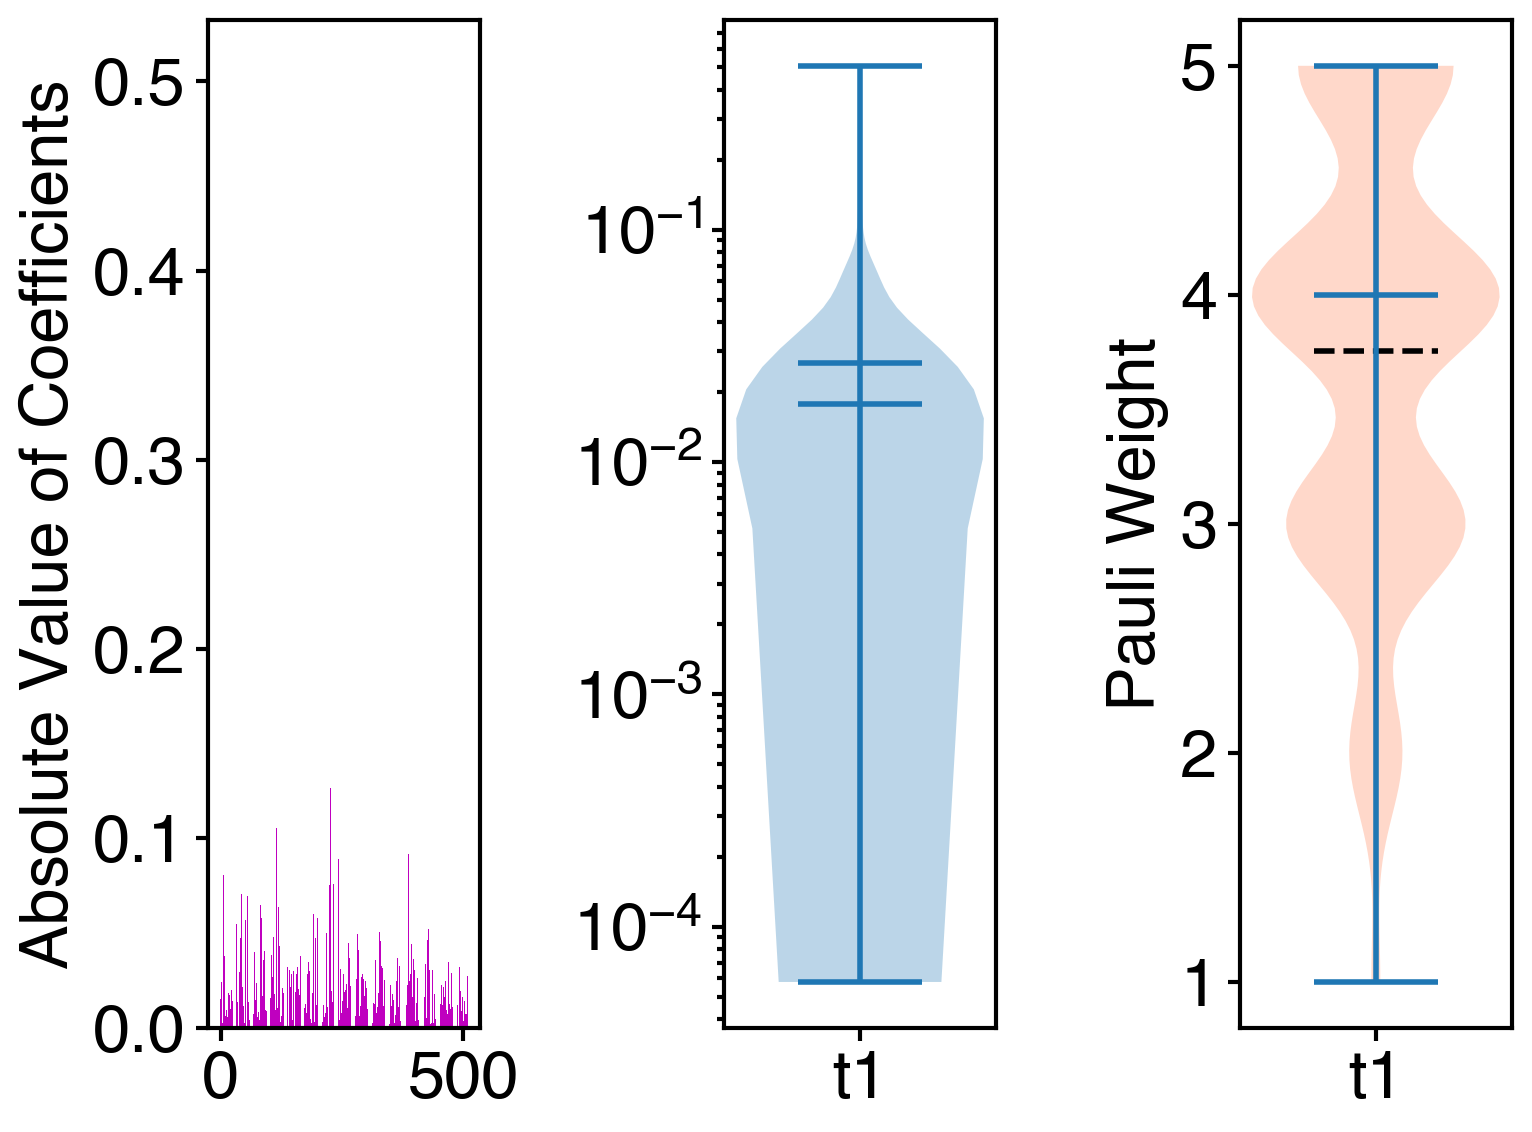

In [8]:
sim_exact = Simulation.from_pauli_list(obs, op_seq, threshold=0.0)
# assert(np.allclose(sim_exact.run_circuit(), (0.005222428557558277+0j)))
sim_exact.run()
sim_exact.observable.coeffs
# print(sim_exact.observable.bits)
# print(len(sim_exact.observable.coeffs))
coeffs_abs = np.abs(sim_exact.observable.coeffs)

evo_ob = sim_exact.observable.to_sparse_pauli_op(nq)
pauli_weights = [count_weight(pstr.to_label()) for pstr in evo_ob.paulis]

# plot the distribution absolute values of the coefficients as a volin
fig, axes = plt.subplots(1, 3)
axes[0].bar(range(sim_exact.observable.size()), coeffs_abs, color='m')
# axes[0].set_xlabel('Coefficient Index'); 
axes[0].set_ylabel('Absolute Value of Coefficients')
# axes[0].set_yscale('log')
axes[1].violinplot(coeffs_abs, showmeans=True, showmedians=True, showextrema=True)
axes[1].set_yscale('log')
axes[1].set_xticks([y + 1 for y in range(len([1]))], labels=['t1'])
axes[2].set_xticks([y + 1 for y in range(len([1]))], labels=['t1'])
vp = axes[2].violinplot(pauli_weights, showmeans=True, showmedians=True, showextrema=True)
axes[2].set_ylabel('Pauli Weight')
# Change face color
for body in vp['bodies']: body.set_facecolor('coral')
vp['cmeans'].set_color('black')    # Change mean line color to black
vp['cmeans'].set_linestyle('--')

fig.savefig('pauli_distr.pdf', dpi=300, bbox_inches='tight')
# plt.xticks(range(len(sim_exact.observable.coeffs)))

508


Text(0.5, 1.0, 'Distribution of Absolute Values of Coefficients')

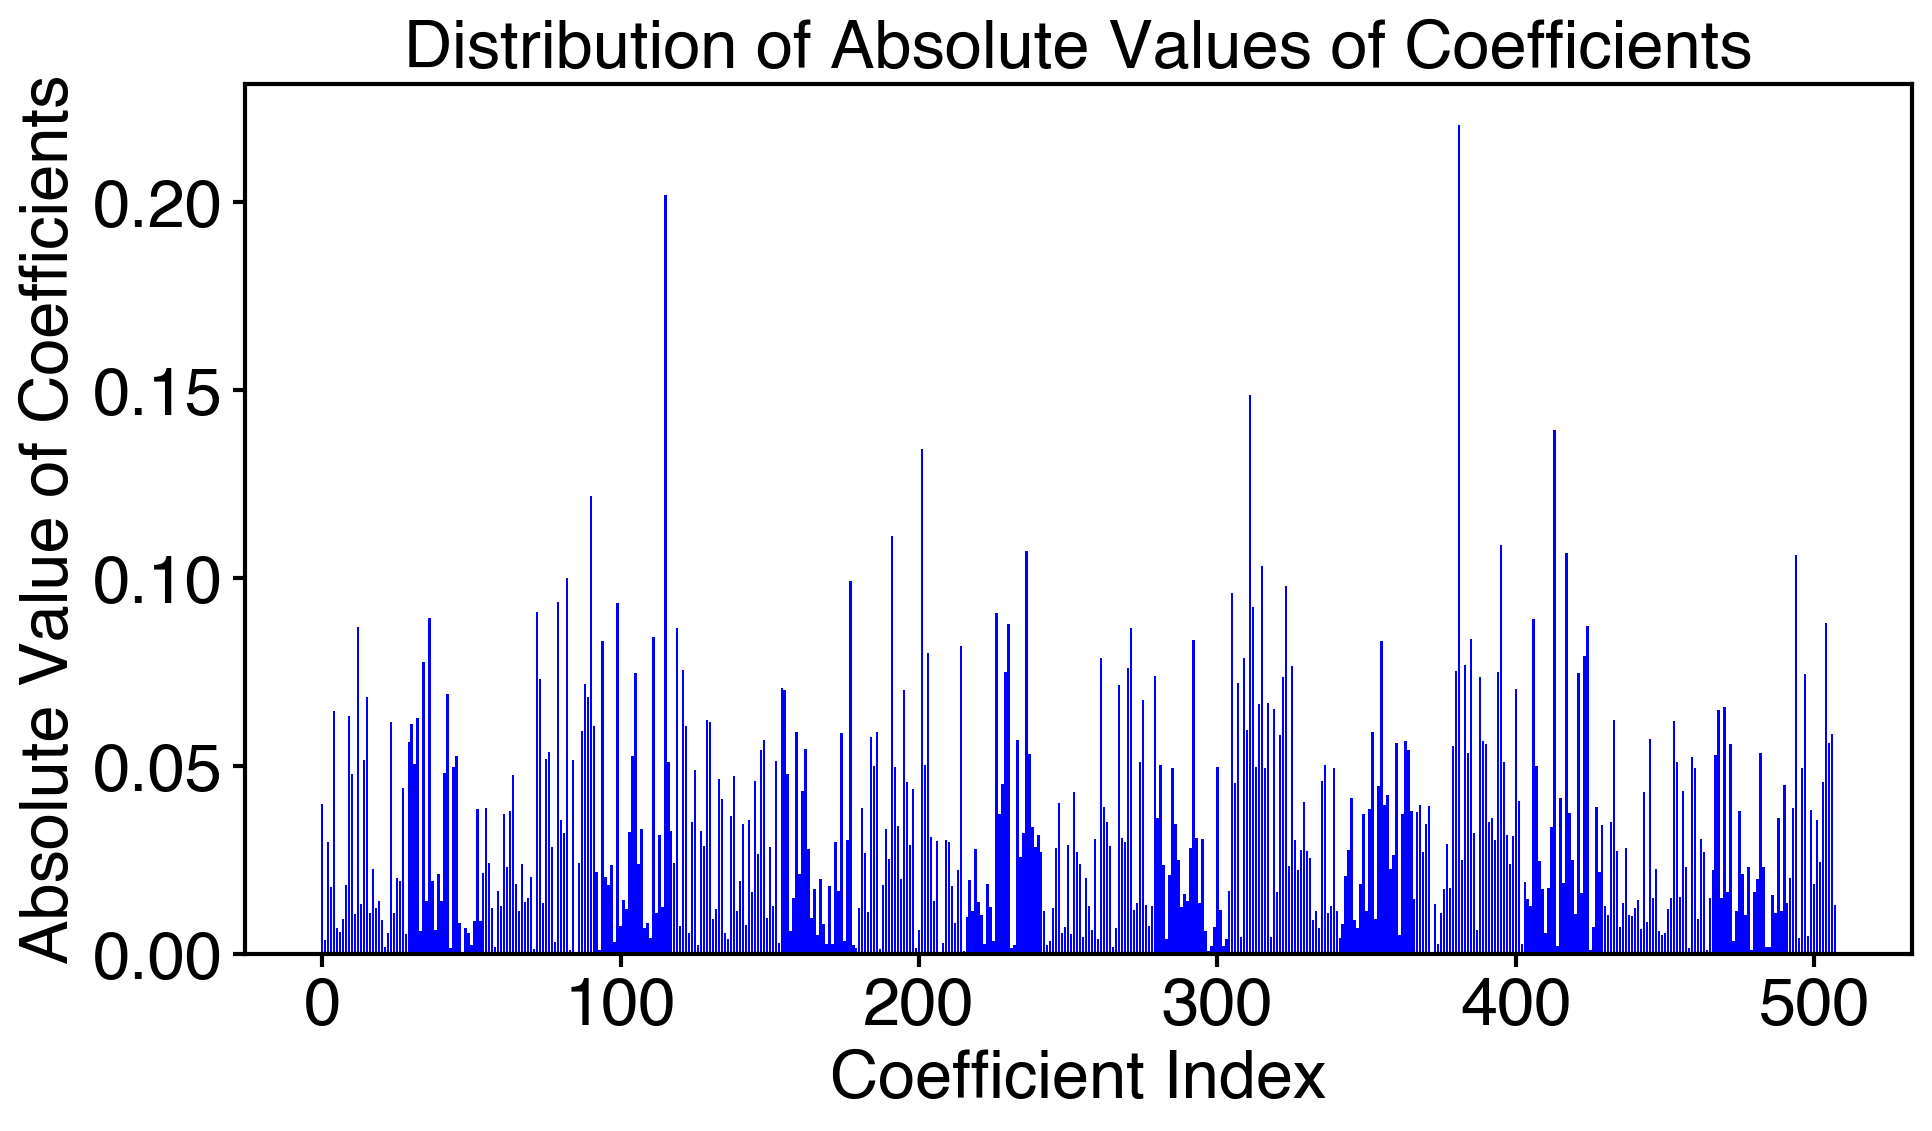

In [137]:
sim_appro = Simulation.from_pauli_list(obs, op_seq, threshold=0.0001)
# assert(np.allclose(sim.run_circuit(), (0.005074072851170014-6.95027693594331e-18j)))
sim_appro.run()
sim_appro.observable.coeffs
print(len(sim_appro.observable.coeffs))

plt.figure(figsize=(10, 6))
plt.bar(range(len(sim_appro.observable.coeffs)), np.abs(sim_appro.observable.coeffs), color='blue')
plt.xlabel('Coefficient Index'); plt.ylabel('Absolute Value of Coefficients'); plt.title('Distribution of Absolute Values of Coefficients')
# plt.xticks(range(len(sim_appro.observable.coeffs)))

### Clifford transformation

Before running the calculation, we can transform the angles to bring them into the range [-pi/4, pi/4] (or in the notation of the code, coefficients will be [-pi/8, pi/8]).
This is done at the OperatorSequence level using the reduce_clifford function. It will transform all the Pauli rotation gates inside and also store the Clifford operators
in clifford_ops. Then, the Clifford layer can be applied to the observable and now we are again left only with non-Clifford Pauli rotation gates that can be simulated with SPD.

As shown below, this procedure does not change the final results, but could affect the speed when using a non-zero threshold because it will minimize the number of insertions/deletions of Paulis.

In [5]:
q = 5
nsteps = 3
obs = PauliList(['ZZIII'])
A_op = PauliList(['YYIYI', 'IYYII', 'IIYIY', 'IYYYI', 'YIYII'])
B_op = PauliList(['ZIIII', 'IZIII', 'IIZII', 'IIIZI', 'IIIIZ'])
ops = [A_op, B_op]*nsteps 
coeffs = [[0.85 for _ in range(nq)] for i in range(2*nsteps)] 
op_seq = OperatorSequence(ops, coeffs)
op_seq.reduce_clifford()
obs = op_seq.clifford_ops.apply_to_PauliList(obs)
op_seq = op_seq.to_sparse_pauli_list()

In [6]:
sim = Simulation.from_pauli_list(obs, op_seq, threshold=0.0)
assert(np.allclose(sim.run_circuit(), (0.0052224285575582854+1.528991154698683e-17j)))

In [7]:
sim = Simulation.from_pauli_list(obs, op_seq, threshold=0.0001)
assert(np.allclose(sim.run_circuit(), (0.0050740728511700275-7.12841280550884e-17j)))